In [1]:
%load_ext autoreload
%autoreload 2


## Data

### Ru Freq

In [88]:
import pandas as pd

ru_freq_data = pd.read_csv("data/freqrnc2011.csv", sep='\t')

ru_freq_data.head()


,Lemma,PoS,Freq(ipm),R,D,Doc
0,а,conj,8198.0,100,97,32332
1,а,intj,19.8,99,90,757
2,а,part,6.1,59,79,128
3,а,s,2.7,59,85,160
4,аа,intj,1.5,47,80,68


In [ ]:
ru_freq_data = ru_freq_data[ru_freq_data['Lemma'].str.isalpha()]


In [90]:
ru_freq_data['Lang'] = "RU"


In [91]:
cefr = pd.qcut(ru_freq_data["Freq(ipm)"], [.0, .25, .5, .75, .9, .95, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [92]:
ru_freq_data["Level"] = cefr


In [93]:
ru_freq_data[ru_freq_data['Lemma'].str.contains('-')]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level


In [94]:
ru_freq_data[cefr=="C2"]


,Lemma,PoS,Freq(ipm),R,D,Doc,Lang,Level
15,аберрация,s,0.7,36,79,50,RU,C2
19,абонементный,a,0.4,24,76,30,RU,C2
22,абордаж,s,0.5,38,85,44,RU,C2
36,абсолютизация,s,0.6,21,71,36,RU,C2
37,абсолютизировать,v,0.5,30,78,41,RU,C2
...,...,...,...,...,...,...,...,...
52119,ятаган,s,0.6,24,75,37,RU,C2
52123,яхтсмен,s,0.5,19,72,22,RU,C2
52124,ячеистый,a,0.7,24,72,34,RU,C2
52134,ящерка,s,0.4,27,82,33,RU,C2


### Eng Freq

In [43]:
import pandas as pd

eng_freq_data = pd.read_csv("data/I159729.csv")

eng_freq_data.head()


,Word,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy
0,a,1,10610626,16.18,798.92,-0.01,333.85,24.0,0.73
1,aah,3,222,5.40,816.43,0.21,186.03,21.0,0.62
2,Aaron,5,10806,9.29,736.06,-0.11,289.01,32.0,0.97
3,aback,5,387,5.96,796.27,0.11,171.61,15.0,0.45
4,abacus,6,513,6.24,964.40,0.65,489.00,15.0,0.47


In [44]:
eng_freq_data = eng_freq_data.rename(columns={"Word": "Lemma"})
eng_freq_data["Lang"] = "ENG"


In [45]:
eng_freq_data = eng_freq_data[eng_freq_data["Freq_HAL"] != 0]
eng_freq_data = eng_freq_data[eng_freq_data["Lemma"].str.isalpha()]


In [46]:
eng_freq_data[eng_freq_data['Lemma'].str.contains("\\d", regex=True)]


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang


In [47]:
cefr = pd.qcut(eng_freq_data["Freq_HAL"], [.0, .25, .5, .75, .9, .95, 1], ["C2", "C1", "B2", "B1", "A2", "A1"])


In [48]:
eng_freq_data["Level"] = cefr


In [49]:
eng_freq_data[eng_freq_data["Level"] == "C2"]


,Lemma,Length,Freq_HAL,Log_Freq_HAL,I_Mean_RT,I_Zscore,I_SD,Obs,I_Mean_Accuracy,Lang,Level
9,abase,5,30,3.40,803.27,0.03,309.52,22.0,0.69,ENG,C2
10,abasement,9,7,1.95,1037.06,0.92,311.84,17.0,0.53,ENG,C2
11,abash,5,1,0.00,748.71,0.23,194.37,21.0,0.68,ENG,C2
14,abbess,6,33,3.50,885.14,0.28,324.20,7.0,0.22,ENG,C2
21,abdicate,8,118,4.77,1056.00,0.84,475.66,18.0,0.56,ENG,C2
...,...,...,...,...,...,...,...,...,...,...,...
40440,zealotry,8,62,4.13,1077.86,0.90,735.27,7.0,0.23,ENG,C2
40444,zeitgeist,9,111,4.71,1129.75,1.15,338.49,4.0,0.13,ENG,C2
40453,zigzag,6,110,4.70,785.26,-0.07,254.95,34.0,1.00,ENG,C2
40454,zigzagging,10,16,2.77,955.40,0.32,383.98,25.0,0.78,ENG,C2


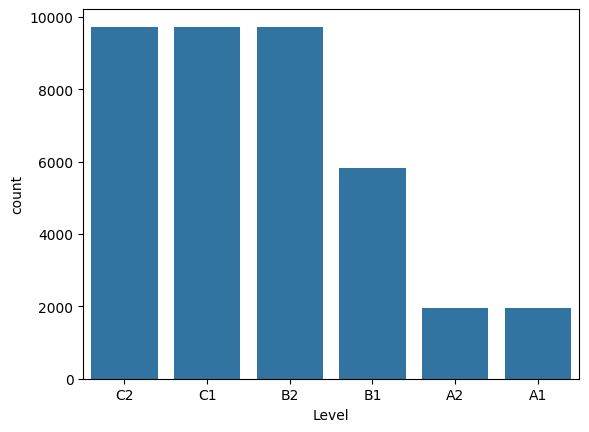

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(eng_freq_data, x="Level")
plt.show()


### Ru CEFR

### Eng CEFR

## Dataset

In [133]:
data = eng_freq_data


In [134]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.3, stratify=data['Level'])


In [146]:
from tokenizer import get_bpe_tokenizer, get_char_tokenizer, ENGALPHAPBET

MAX_LEN = 16

tokenizer = get_char_tokenizer(ENGALPHAPBET, MAX_LEN)


In [154]:
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id


In [148]:
from dataset import LLLDataset, LEVELS, LANGUAGES, NUM_LEVELS, NUM_LANGS

dataset = LLLDataset(data[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [149]:
train_set = LLLDataset(train[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)
test_set = LLLDataset(test[["Lemma", "Level", "Lang"]], tokenizer, max_len=MAX_LEN)


In [150]:
from torch.utils.data import Subset
import numpy as np

small_set = Subset(train_set, np.random.choice(np.arange(len(train_set)), size=32, replace=False))


In [151]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=16, drop_last=False, shuffle=False)
small_loader = DataLoader(small_set, batch_size=4, drop_last=True, shuffle=True)


## Utils

In [59]:
import torch 

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'


print(f'using {device} device')


using mps device


In [60]:
import os.path

BASE_PATH = './checkpoints/'
get_path = lambda model_name: os.path.join(BASE_PATH, model_name)


In [61]:
import torch.nn as nn

def get_model_device(model: nn.Module):
    return next(model.parameters()).device


## Train

In [165]:
MODEL_NAME = "TestModel"


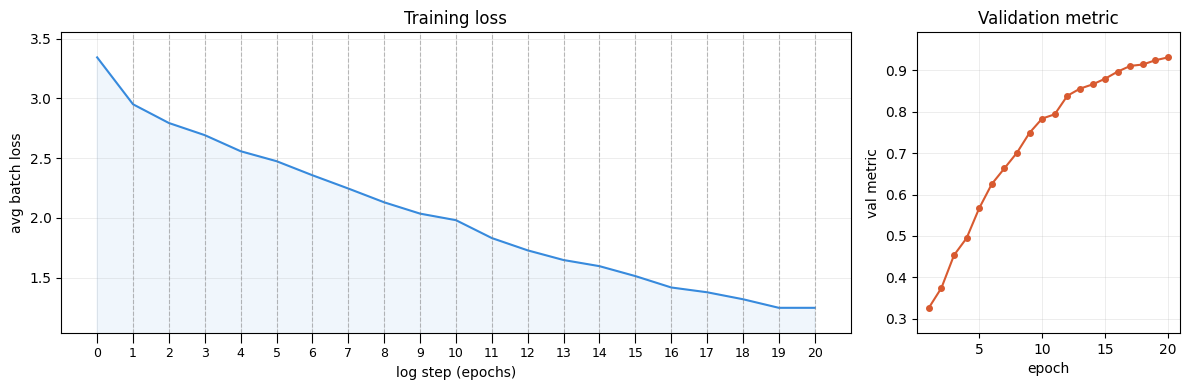

In [167]:
import torch.optim as optim
from model import LLTransformer
from utils.logger import PlotLogger, TQDMLogger
from utils.checkpointer import CheckPointer
from utils.trainer import LLTrainer
from utils.func import n_params
from utils.metrics import TokenCrossEntropyLoss, TokenAccuracy


vocab_size = len(tokenizer.get_vocab()) + len(tokenizer.get_added_vocab())
model = LLTransformer(
    vocab_size=vocab_size,
    d_model=256,
    nhead=4,
    num_layers=3,
    dim_feedforward=1024,
    num_levels=NUM_LEVELS,
    max_positions=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.2,
).to(device)

print(f"Trainable params: {n_params(model):,}")

chkpter = CheckPointer(model, get_path(MODEL_NAME))
logger = PlotLogger(log_every_n_step=100)
trainer = LLTrainer(model, logger, device, chkpter)

train_params = {
    'criterion': TokenCrossEntropyLoss(ignore_index=PAD_IDX),
    'opt': optim.AdamW(model.parameters(), lr=1e-4)
}

val_params = {
    'metric': TokenAccuracy(vocab_size, PAD_IDX),
    # 'transform': nn.Sigmoid()
}

model = trainer.fit(small_loader, train_params, small_loader, val_params, epochs=20)


In [156]:
tokenizer.save_pretrained(get_path(MODEL_NAME))


('./checkpoints/EngCharLLTransformer/tokenizer_config.json',
 './checkpoints/EngCharLLTransformer/added_tokens.json')

In [157]:
trainer.logger.save(trainer.chkpter.chkpt_path)


## Eval

In [158]:
from torch.nn.functional import softmax
import torch 
from dataset import level2idx, lang2idx


@torch.no_grad()
def generate_word(model, level, lang, tokenizer, device, max_len=32, temperature=0.8, do_sample=True):
    model.eval()

    level_idx = torch.tensor([level2idx[level]], device=device)

    generated = [BOS_IDX]

    # with torch.no_grad():
    for _ in range(max_len):
        input_ids = torch.tensor([generated], device=device)
        attention_mask = torch.ones_like(input_ids, device=device)

        logits = model(input_ids, level_idx, attention_mask)
        next_token_logits = logits[0, -1, :] / temperature


        if do_sample:
            probs = softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()
        else:
            next_token = torch.argmax(next_token_logits).item()
        if next_token == EOS_IDX:
            break

        generated.append(next_token)

    decoded = tokenizer.decode(generated[1:], skip_special_tokens=True)

    word = decoded.strip().replace(' ', '')
    return word


In [164]:
generate_word(model, "C2", "RU", tokenizer, device, max_len=MAX_LEN, do_sample=True, temperature=.8)


'topperly'